In [1]:
import numpy as np


def unequal_width_complement_peaks(num_bits, eps0, eps1, weight0=0.5, dtype=np.float64):
    """
    Exact distribution:
        P(x) = weight0 * G_eps0^{0^N}(x)
             + (1 - weight0) * G_eps1^{1^N}(x)

    where
        G_eps^a(x) = prod_i [(1-eps) if x_i=a_i else eps].

    Args:
        num_bits: number of bits N.
        eps0: noise width around 0^N. Must satisfy 0 <= eps0 <= 1.
        eps1: noise width around 1^N. Must satisfy 0 <= eps1 <= 1.
        weight0: mixture weight for peak around 0^N.
        dtype: numpy dtype.

    Returns:
        p: numpy array of length 2**num_bits.
           p[x] is the probability of bitstring x in integer order.
    """

    if num_bits < 1:
        raise ValueError("num_bits must be positive.")

    if not (0.0 <= eps0 <= 1.0):
        raise ValueError("eps0 must be in [0,1].")

    if not (0.0 <= eps1 <= 1.0):
        raise ValueError("eps1 must be in [0,1].")

    if not (0.0 <= weight0 <= 1.0):
        raise ValueError("weight0 must be in [0,1].")

    dim = 2 ** num_bits
    x = np.arange(dim, dtype=np.uint64)

    # Hamming weight of each bitstring x
    hamming_weight = np.array([int(i).bit_count() for i in x], dtype=np.int64)

    w = hamming_weight
    N = num_bits

    # Distance from 0^N is w
    G0 = (1.0 - eps0) ** (N - w) * (eps0 ** w)

    # Distance from 1^N is N - w
    G1 = (1.0 - eps1) ** w * (eps1 ** (N - w))

    p = weight0 * G0 + (1.0 - weight0) * G1
    p = p.astype(dtype)

    # Numerical cleanup
    p /= p.sum()

    return p

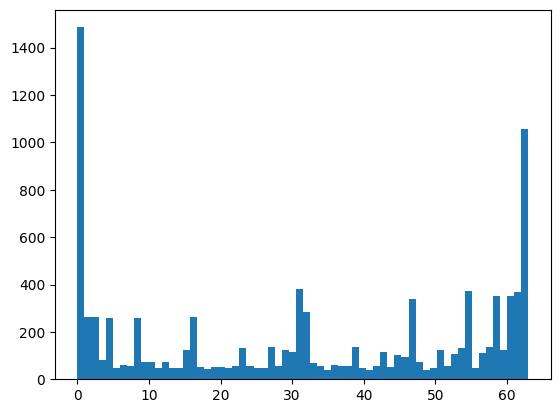

In [3]:
n = 6
eps0 = 0.05
eps1 = 0.20

p_mix = unequal_width_complement_peaks(
    num_bits=6,
    eps0=0.15,
    eps1=0.25,
    weight0=0.4
)

samples=10000
def sample_target_function():
    x=range(2**n)
    ret = np.random.choice(x,samples,p=p_mix)
    return ret.copy()

import matplotlib.pyplot as plt
opt_hist=plt.hist(sample_target_function(),bins=2**n)


In [5]:
np.savetxt('peaked_dist',p_mix)